# Transformers

## Begin with a concrete question: which parts of a sequence belong together?

Consider the sentence “The puppy carried the ball.” To represent “carried,” a model may need information about the puppy and the ball. In a longer sentence, the relevant words might be separated by many positions. The model needs a way to combine information across the sequence while retaining which position each representation describes.

A **Transformer** repeatedly updates a vector for every position. Attention lets positions read information from other allowed positions. A feed-forward network refines the features at each position. Residual connections preserve direct paths through the stack, and normalization helps manage the scale of intermediate representations.

We will follow token IDs, embeddings, order information, attention, refinement, and a prediction loss. Small arithmetic examples expose each mechanism; they are not a trained language model. [Attention Mechanism](26_Attention_Mechanism_Notes.ipynb) provides the detailed weighted-read calculation.

The [code companion](27_Transformers.ipynb) defines a pre-normalized block and the embedding, position, and head modules. It executes a causal forward pass and checks that changing a future token leaves earlier outputs unchanged. The full forward walkthrough below explains how those pieces connect.


## See the whole journey before inspecting a block

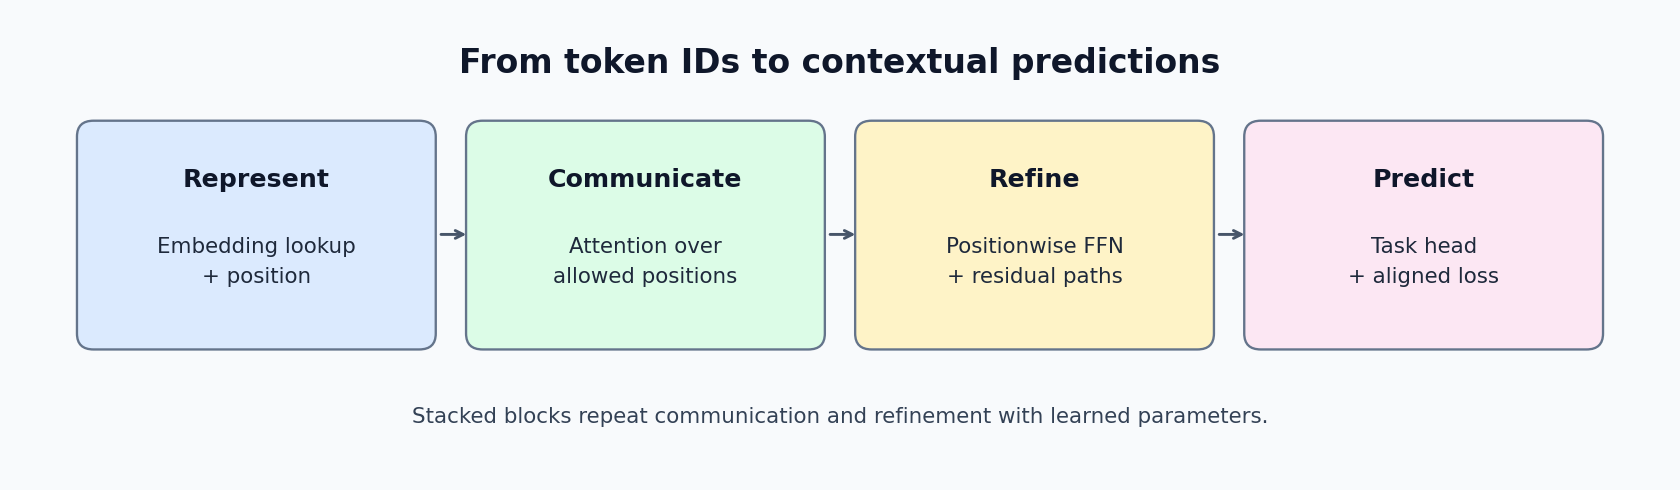

| Stage | Input | Output | Purpose |
| --- | --- | --- | --- |
| Tokenization | Text | Token IDs | Define discrete input units |
| Embedding | IDs | Content vectors | Learn a numerical representation |
| Position information | Indices or relative relationships | Order-aware computation | Make sequence structure available |
| Transformer stack | Position vectors | Contextual vectors | Exchange and refine information |
| Task head | Final vectors | Logits or numerical outputs | Define the prediction |
| Loss | Outputs and aligned targets | Scalar objective | Supply the training signal |

A block does not produce a sentence by itself. It produces updated numerical representations. The head and training objective determine whether these representations support classification, labeling, generation, or another task.

A Transformer can operate on image patches, measurements, or other units too. The tokenization and output contract change, while the communication/refinement pattern remains useful.


## Token IDs are addresses, not measurements

A tokenizer may divide text into complete words, word fragments, punctuation, or special markers. The assigned ID is an address into a learned embedding table. ID five is not semantically “larger” than ID two.

Suppose a tiny vocabulary assigns `puppy` ID 5 and `ball` ID 3. An embedding table $E\in\mathbb R^{V\times D}$ contains one width-$D$ vector per vocabulary entry. Looking up IDs $[1,5,3,2]$ selects four rows; it does not multiply their meanings by the IDs.

| Quantity in the companion | Value | Meaning |
| --- | --- | --- |
| Vocabulary size $V$ | 12 | Number of embedding rows |
| Model width $D$ | 8 | Coordinates per position |
| Sequence length $L$ | 4 | Number of selected token IDs |
| Batch size $B$ | 1 | Number of examples |
| Embedding output | $(1,4,8)$ | One vector per input position |

The table starts from initialized numbers and is adjusted through learning. Similar vectors may be useful for similar contexts, but no coordinate is guaranteed to have a specific human-readable meaning.


## Add order without treating token IDs as positions

Unrestricted self-attention based only on token content does not intrinsically assign “first” or “next” to a position. A common design adds a position vector to each token embedding:

$$X_{b,t}=E_{id_{b,t}}+P_t.$$

For a width-two teaching example, choose content vector $[0.2,-0.1]$. At position zero, add $[0,1]$ to get $[0.2,0.9]$. At position one, add approximately $[0.841471,0.540302]$ to get $[1.041471,0.440302]$.

The same token now enters the block differently at two positions. Adding preserves width; concatenation would increase it and require another design decision. The block must learn how to use the resulting information.

The companion uses a learned position table with six rows and width eight. Its four token positions fit inside that table. Learned absolute tables need defined handling when a requested index exceeds their supported range. [Positional Encoding](28_Positional_Encoding_Notes.ipynb) compares fixed, learned, relative, and rotary approaches.


## Attention mixes positions using learned matches

For incoming representations $X$, learned projections produce $Q=XW^Q$, $K=XW^K$, and $V=XW^V$. One attention head reads:

$$A=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}+M\right),\qquad O=AV,$$

where $M$ is an additive availability mask. Softmax operates over keys for every query. Values supply the content being mixed.

A scalar example with scores $[0,1]$ gives weights $[0.268941,0.731059]$. Reading values $[2,6]$ returns approximately 4.924234. This numerical example illustrates a soft blend; it does not assign literal scalar values to words.

In self-attention, queries, keys, and values originate from the same sequence. Each output still belongs to its query position. Attention does not collapse the entire sequence into one vector unless a specific readout is designed to do so.

Multiple heads learn several projected matching spaces and combine their outputs. Their detailed dimensions and arithmetic appear in [Multi-Head Attention](29_Multi_Head_Attention_Notes.ipynb).


## Refinement mixes features within each position

A common feed-forward network expands the feature width and then returns it to the model width:

$$\operatorname{FFN}(x)=\phi(xW_1+b_1)W_2+b_2.$$

For model width eight and intermediate width sixteen, $W_1$ has shape $8\times16$ and $W_2$ has shape $16\times8$ under row-vector notation. The activation $\phi$ introduces nonlinearity; the companion uses GELU.

The same feed-forward parameters are applied independently at every position. This mixes feature coordinates within a token representation. It does not directly average or exchange information across positions; attention provides that exchange.

As a separate ReLU teaching example, let $x=[1,-1]$, first transform $xW_1=[1,-1,0]$, and activation output $[1,0,0]$. Choose $W_2$ so its first row is $[0.5,0.25]$ and other rows contribute zero. The FFN output is $[0.5,0.25]$.

This example exposes the expand–activate–project pattern. It is not the companion's GELU layer or a claim about its initialized weights.


## Preserve a direct path with residual additions

A residual connection adds a learned update to the representation that entered a sublayer. If attention supplies update $a$, then $u=x+a$. The next sublayer supplies another update rather than replacing the state unconditionally.

| Step in a width-two example | Vector |
| --- | --- |
| Incoming $x$ | $[1,-1]$ |
| Attention update $a$ | $[0.2,0.3]$ |
| After first residual $u=x+a$ | $[1.2,-0.7]$ |
| FFN update $f$ | $[-0.1,0.4]$ |
| After second residual $y=u+f$ | $[1.1,-0.3]$ |

The updates are selected numbers, not the output of a trained block. They show why sublayer outputs must match the model width: coordinatewise addition requires compatible shapes.

A direct identity route also contributes to gradient flow through a stack. It does not make the network immune to unstable training or guarantee that old information survives unchanged. Learned updates can still substantially alter the representation.


## Normalize features within a position

Layer normalization computes statistics across the feature coordinates of one position. For feature vector $x$ of width $D$:

$$\mu=\frac1D\sum_jx_j,\qquad v=\frac1D\sum_j(x_j-\mu)^2,$$
$$LN(x)_j=\gamma_j\frac{x_j-\mu}{\sqrt{v+\epsilon}}+\beta_j.$$

The variance here divides by $D$, not $D-1$. $\epsilon$ avoids division by zero, and learned $\gamma,\beta$ allow rescaling and shifting.

For $x=[1,3]$, mean is two and variance is one. With $\gamma=[1,1]$, $\beta=[0,0]$, and $\epsilon=10^{-5}$, the result is approximately $[-0.999995,0.999995]$.

LayerNorm does not fit a dataset-wide scaler and does not compute these statistics across the sequence's time dimension in this design. It is distinct from the train-only preprocessing in the sequence-modeling lesson and from batch normalization. Normalization changes the input supplied to a sublayer while residual connections preserve another route.


## Follow the companion's pre-normalized block

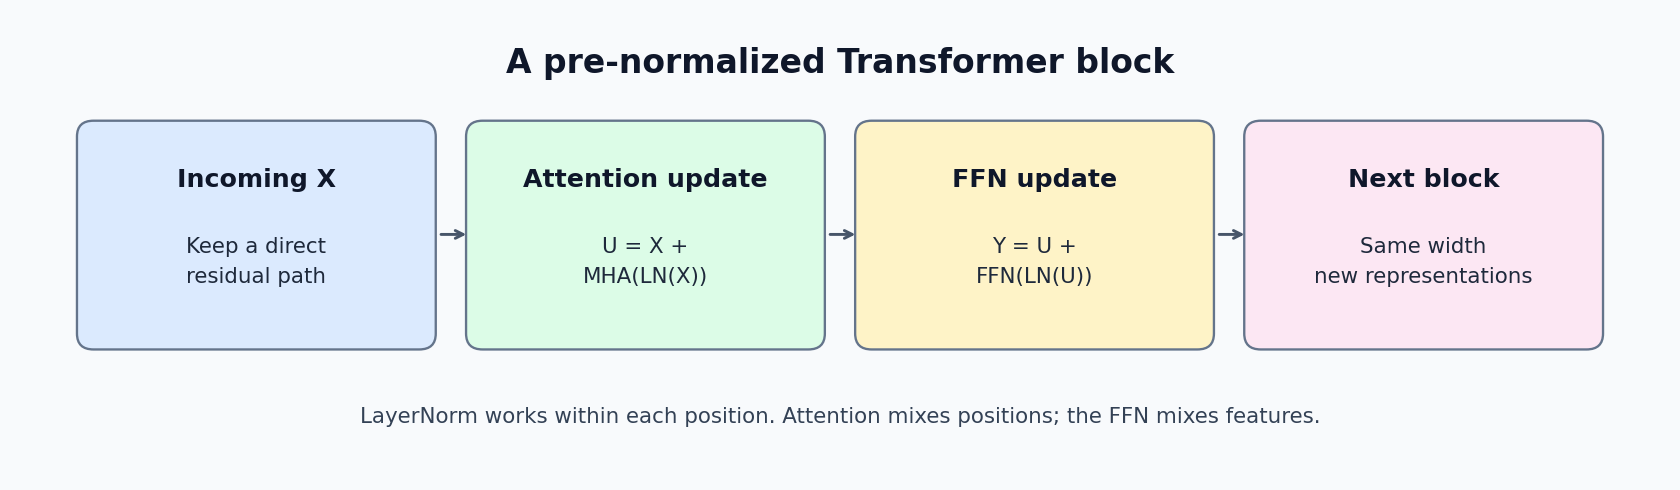

The companion implements:

$$U=X+\operatorname{MHA}(LN_1(X),LN_1(X),LN_1(X)),$$
$$Y=U+\operatorname{FFN}(LN_2(U)).$$

In its code, the first normalized tensor is computed once and supplied as query, key, and value. The attention mask is passed to the attention layer. The feed-forward network expands eight coordinates to sixteen and returns eight coordinates.

A post-normalized arrangement places normalization after residual addition, such as $U=LN(X+\operatorname{MHA}(X))$. These are different computations. Keep the chosen order explicit rather than moving normalization around in a diagram as if it had no effect.

The shown equations omit optional dropout. They describe the companion's structure, not every Transformer implementation. Stacking blocks supplies repeated rounds of interaction; separate blocks usually own separate parameters.


## Trace the shapes all the way to the task head

| Stage in the companion configuration | Shape |
| --- | --- |
| Token IDs | $(1,4)$ |
| Position indices | $(1,4)$ |
| Token and position embeddings | $(1,4,8)$ each |
| Combined representations | $(1,4,8)$ |
| Normalized representations | $(1,4,8)$ |
| Two-head attention output | $(1,4,8)$ |
| FFN intermediate | $(1,4,16)$ |
| Block output | $(1,4,8)$ |
| Vocabulary logits from head | $(1,4,12)$ |

The head is a linear map from eight features to twelve vocabulary scores. It does not automatically select or sample a token. Training compares the logits with aligned labels, and generation applies a defined selection procedure.

The companion executes this forward trace and verifies the embedding, hidden-state, and logit shapes. Its causal perturbation check tests visibility. For repeated training and held-out results, continue to the lesson 32 project.


## Connect the head to a numerical loss and update

Suppose a two-class head outputs logits $[0,1]$ for one representation and the correct class is the second. Softmax gives $[0.268941,0.731059]$, and cross-entropy is $-\ln(0.731059)\approx0.313262$.

For logits $z_j$, the derivative is $\partial L/\partial z_j=p_j-\mathbf1[j=y]$. Here the derivatives are approximately $[0.268941,-0.268941]$.

To isolate one learnable quantity, treat these logits as two head biases with all other contributions fixed. An SGD step at learning rate 0.1 changes them to $[-0.026894,1.026894]$. The correct-class probability increases because its logit rises relative to the other.

A full head has weight gradients too: each class's logit derivative multiplies the incoming representation. Backpropagation continues through the Transformer stack, embeddings, and position parameters. The loss learns the entire computation, rather than training attention weights in isolation.

For next-token prediction, the same principle applies to a vocabulary-sized logit vector at every valid position. Padding targets must be excluded according to the chosen loss contract.


## Masks and target shifts determine what may be predicted

For token sequence `[BOS, puppy, runs, EOS]`, one training pair is input `[BOS, puppy, runs]` and labels `[puppy, runs, EOS]`. A causal mask lets each input position read only itself and earlier input positions.

| Input position | Input token | Next-token label | Allowed input context |
| --- | --- | --- | --- |
| 0 | BOS | puppy | BOS |
| 1 | puppy | runs | BOS, puppy |
| 2 | runs | EOS | BOS, puppy, runs |

The shift prevents the answer from being the current input; the mask prevents later input positions from exposing it. Both matter. A padding mask additionally prevents artificial positions from supplying content.

In `nn.MultiheadAttention`, Boolean `True` in the attention mask blocks a relationship; see the [official mask specification](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html). A mask rule applies to representations too: if an upstream module already mixed in forbidden future information, a later causal attention mask cannot remove that leakage automatically.


## Distinguish the three common Transformer arrangements

| Arrangement | Main information flow | Common task shape |
| --- | --- | --- |
| Encoder-only | Input positions read allowed input context in both directions | Classification or labeling |
| Decoder-only | Each position reads its prefix | Next-token prediction and generation |
| Encoder–decoder | Decoder prefix reads an encoded source through cross-attention | Source-to-target transformation |

An encoder's output is a contextual sequence, not inherently a class label. A decoder's output is a sequence of vectors, not inherently generated text. The head, inputs, mask, and objective complete the model.

During causal training, true prefix tokens are supplied, so many positions can be calculated in parallel. During generation, each newly selected token changes the prefix for the next step. Generation therefore proceeds sequentially across newly produced tokens even though work within a step can be parallelized.

Caching earlier keys and values can avoid recomputing unchanged prefix projections. It is a computational technique, not permission to read future tokens. [Transformer Encoder and Decoder](30_Transformer_Encoder_and_Decoder_Notes.ipynb) traces the two-stream arrangement in detail.


## Understand the useful structure and its cost

A recurrent network computes each new state from the previous state. Attention directly connects permitted positions within a layer. In an unrestricted encoder, a distant position can supply a value in one attention step rather than requiring a chain of recurrent transitions.

Dense self-attention compares $L^2$ position pairs per head. Length ten gives 100 pairs, while length twenty gives 400. A causal mask restricts usable relationships but does not make the asymptotic pair count linear. Efficient implementations can reduce stored intermediate memory without eliminating the dense interaction count.

| Choice | What it changes |
| --- | --- |
| Longer context | Number of position pairs and available evidence |
| Wider representation | Projection and feature-processing work |
| More layers | Number of refinement rounds and parameters |
| More heads at fixed width | Partition of projected feature channels |
| Wider FFN | Positionwise feature capacity and computation |

This flexibility can be useful, but model size and context do not guarantee accuracy. Correct targets, enough relevant training data, validation, and comparisons with simpler baselines remain necessary.


## Diagnose a Transformer before making it larger

| Symptom | Investigation |
| --- | --- |
| Early logits change with a future-token edit | Causal mask and all upstream mixing |
| Identical tokens cannot be distinguished by order | Position information and indexing |
| Residual addition fails | Sublayer output/model-width mismatch |
| Loss is low but generation drifts | Teacher-forced versus free-running evaluation |
| Padding changes a sequence summary | Key mask, query handling, and readout |
| Manual calculations differ from a library | Projections, dropout, normalization order, and biases |

When inspecting a mask or comparing deterministic calculations, use evaluation behavior and explicitly control dropout. Initialized random modules can produce valid tensors without any useful task behavior. A forward pass demonstrates an interface; fitting demonstrates learning on examples; a held-out evaluation addresses generalization.

Keep these forms of evidence separate so an attractive diagram or a successful shape assertion does not become an unsupported performance claim.


## Practice the block and retain the complete workflow

1. Does token ID five mean that token has five times the meaning of token ID one?
2. Which sublayer directly mixes information between positions?
3. What shape follows a width-eight FFN's projection back from width sixteen?
4. Why are both shifted targets and a causal mask needed?
5. Can a correct forward shape establish that the model learned a language task?

**Answers.** IDs are lookup addresses, not semantic measurements. Attention mixes positions; the FFN refines features positionwise. The output returns to width eight so residual addition is possible. Shifting separates current inputs from next-token labels, and masking prevents later inputs from revealing those labels. Shape correctness alone establishes no trained capability.

**Remember:** represent content and order, communicate through attention, refine positionwise, retain residual paths, and predict through a task head. Training supplies the objective that makes these operations useful.

Continue with [Positional Encoding](28_Positional_Encoding_Notes.ipynb) and [Multi-Head Attention](29_Multi_Head_Attention_Notes.ipynb) to examine the two major mechanisms introduced here.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
